<a href="https://colab.research.google.com/github/wjdwogns2873-web/deep-learning-study/blob/main/02_Digit_Recognizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. 구글 드라이브 연결 (로그인 팝업이 뜨면 확인만 눌러주세요)
from google.colab import drive
drive.mount('/content/drive')

# 2. 구글 드라이브에 저장해둔 열쇠(access_token)를 코랩 보안 폴더로 자동 복사
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/Kaggle/access_token ~/.kaggle/
!chmod 600 ~/.kaggle/access_token

# 3. 캐글 API로 MNIST 데이터 초고속 다운로드 및 압축 해제
!pip install -q kaggle

Mounted at /content/drive


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('digit-recognizer')

print("Path to competition files:", path)

100%|██████████| 15.3M/15.3M [00:01<00:00, 13.5MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/digit-recognizer


In [ ]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/root/.cache/kagglehub/competitions/digit-recognizer'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/root/.cache/kagglehub/competitions/digit-recognizer/sample_submission.csv
/root/.cache/kagglehub/competitions/digit-recognizer/test.csv
/root/.cache/kagglehub/competitions/digit-recognizer/train.csv


In [ ]:
import torch

train_df = pd.read_csv('/root/.cache/kagglehub/competitions/digit-recognizer/train.csv')

# train_df.head() # label, pixel0 ~ pixel783

# .values를 붙이면 판다스 표에서 순수한 Numpy 배열로 변환됩니다.
train_labels = train_df['label'].values

train_images = train_df.drop('label', axis=1).values

print(train_images.shape)
print(train_labels.shape)

(42000, 784)
(42000,)


In [ ]:
# numpy 배열을 파이토치가 좋아하는 텐서로 변환하기
X_tensor = torch.FloatTensor(train_images)
y_tensor = torch.LongTensor(train_labels)

# 가장 중요한 차원 변형 (Reshape)
# (42000, 784) -> (42000, 1, 28, 28)
# 여기서 1은 흑백을 의미합니다. 컬러 이미지라면 3이 됩니다.
X_tensor = X_tensor.view(-1, 1, 28, 28)
print(X_tensor.shape)
print(y_tensor.shape)

torch.Size([42000, 1, 28, 28])
torch.Size([42000])


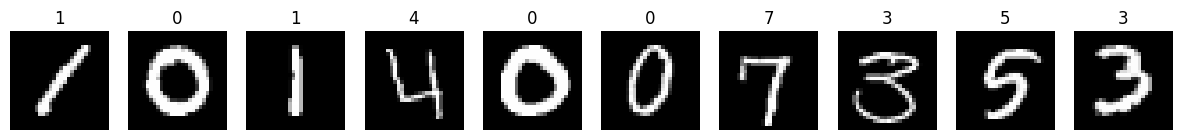

In [ ]:
# @title
# for문으로 여러 개의 이미지를 imshow 하기
import matplotlib.pyplot as plt
num_images = 10

# 가로로 길게 배치하기 위해 matplotlib subplot 생성
fig, axes = plt.subplots(1, num_images, figsize=(15, 2))

for i in range(num_images):
    img = X_tensor[i].squeeze().numpy()
    label = y_tensor[i].item()

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(label)
    axes[i].axis('off')
plt.show()

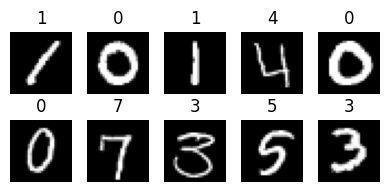

In [ ]:
# @title
# 2행 5열로 총 10개 보여주기
rows = 2
cols = 5
fig, axes = plt.subplots(rows, cols, figsize=(4, 2))

# 2차원 배열 형태인 axes를 1차원으로 쫙 펴주어야(flatten) for문 돌리기 편합니다.
axes = axes.flatten()

for i in range(rows * cols):
    img = X_tensor[i].squeeze().numpy()
    label = y_tensor[i].item()

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(label)
    axes[i].axis('off')
# 이미지들끼리 서로 겹치지 않게 간격 조절
plt.tight_layout()
plt.show()

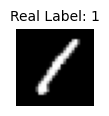

In [ ]:
# 텐서 데이터를 진짜 이미지로 시각화하기
import matplotlib.pyplot as plt
image_index = 0

sample_image = X_tensor[image_index].squeeze().numpy()
sample_label = y_tensor[image_index].item()


plt.figure(figsize=(1, 2))
plt.imshow(sample_image, cmap='gray')
plt.title(f"Real Label: {sample_label}", fontsize=10)
plt.axis('off')
plt.show()

In [ ]:
from torch.utils.data import Dataset, DataLoader

# 파이토치의 Dataset 클래스를 상속받아 나만의 주머니를 만듭니다.
class MNISTDataset(Dataset):
    def __init__(self, images, labels):
        # 부모(Dataset)가 물려줄 초기화 자산이 아무것도 없기 때문에 super().__init__() 안해도 됨.
        self.images = images
        self.labels = labels
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        return image, label

train_dataset = MNISTDataset(X_tensor, y_tensor)

print(len(train_dataset))

42000


In [ ]:
BATCH_SIZE = 64

# shuffle=True를 주면, 매 Epoch마다 마구 섞어서 과적합을 막아줍니다.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 42000 / 64 = 657개의 묶음(Batch)이 만들어집니다.
print(len(train_loader))

657


In [ ]:
batch_images, batch_labels = next(iter(train_loader))
print(batch_images.shape)
print(batch_labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # 흑백 이미지(채널 1개)를 받아서 32개의 특징 지도로 확장합니다.
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) # 학습을 안정화시키는 뼈대
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # 크리를 반으로 줄임 (28 28 -> 14 14)
        self.drop1 = nn.Dropout(0.25) # 과적합 방지용 브레이크 (25% 끄기)

        # 32개에서 64개의 더 복잡한 특징을 잡아내도록 확장합니다.
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2) # 크기를 또 반으로 줄임(14 14 -> 7 7)
        self.drop2 = nn.Dropout(0.25)

        # 이미지 특징들을 1차원으로 쫙 편 뒤, 정답 10개(0~9) 중 하나로 최종 분류합니다.
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.bn5 = nn.BatchNorm1d(128)
        self.drop3 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10) # 최종 출력: 10개의 숫자 노드

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.drop1(self.pool1(x))

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.drop2(self.pool2(x))

        # 배치를 제외한 나머지 차원(64 7 7)을 하나로 쭉 폅니다.
        x = x.view(x.size(0), -1)

        x = F.relu(self.bn5(self.fc1(x)))
        x = self.drop3(x)
        x = self.fc2(x) # 최종 예측 값(Logits)

        return x

model = MNISTCNN()
print(model)

MNISTCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (bn5):

In [ ]:
test_output = model(batch_images)
print(batch_images.shape)
print(test_output.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64, 10])


In [ ]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"현재 사용중인 장치: {device}")

model = model.to(device)

# 손실 함수 정의 (다중 분류 문제이므로 CrossEntropyLoss를 사용합니다.)
criterion = nn.CrossEntropyLoss()

# 옵티마이저 정의
optimizer = optim.Adam(model.parameters(), lr=0.001)

현재 사용중인 장치: cpu


In [ ]:
def train_model(model, train_loader, criterion, optimizer, device):
    # 모델을 훈련 모드로 전환 (Dropout과 BatchNorm이 정상 작동하게 합니다.)
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1) # 가장 높은 점수를 받은 인덱스(0~9) 뽑기
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if (batch_idx + 1) % 100 == 0:
            print(f"Batch {batch_idx+1}/{len(train_loader)} | "
                    f"Loss: {running_loss/(batch_idx+1):.4f} | "
                    f"Accuracy: {100. * correct / total:.2f}%")

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [ ]:
epoch_loss, epoch_acc = train_model(model, train_loader, criterion, optimizer, device)
print(f"[1 Epoch 완료 결과] 최종 Loss: {epoch_loss:.4f} | 최종 Accuracy: {epoch_acc:.2f}")

Batch 100/657 | Loss: 0.6059 | Accuracy: 86.22%
Batch 200/657 | Loss: 0.4027 | Accuracy: 90.91%
Batch 300/657 | Loss: 0.3134 | Accuracy: 92.74%
Batch 400/657 | Loss: 0.2628 | Accuracy: 93.86%
Batch 500/657 | Loss: 0.2303 | Accuracy: 94.53%
Batch 600/657 | Loss: 0.2075 | Accuracy: 94.99%
[1 Epoch 완료 결과] 최종 Loss: 0.1983 | 최종 Accuracy: 95.19


In [ ]:
EPOCHS = 5

history_loss = []
history_acc = []

for epoch in range(EPOCHS):
    print(f"=== Epoch [{epoch+1}/{EPOCHS}] ===")
    epoch_loss, epoch_acc = train_model(model, train_loader, criterion, optimizer, device)

    history_loss.append(epoch_loss)
    history_acc.append(epoch_acc)

    print(f"-> Epoch {epoch + 1} 마감 결과 | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%\n")


=== Epoch [1/5] ===
Batch 100/657 | Loss: 0.0738 | Accuracy: 98.08%
Batch 200/657 | Loss: 0.0709 | Accuracy: 98.16%
Batch 300/657 | Loss: 0.0695 | Accuracy: 98.09%
Batch 400/657 | Loss: 0.0714 | Accuracy: 98.05%
Batch 500/657 | Loss: 0.0708 | Accuracy: 98.07%
Batch 600/657 | Loss: 0.0697 | Accuracy: 98.09%
-> Epoch 1 마감 결과 | Loss: 0.0696 | Accuracy: 98.08%

=== Epoch [2/5] ===
Batch 100/657 | Loss: 0.0589 | Accuracy: 98.22%
Batch 200/657 | Loss: 0.0534 | Accuracy: 98.37%
Batch 300/657 | Loss: 0.0555 | Accuracy: 98.32%
Batch 400/657 | Loss: 0.0565 | Accuracy: 98.33%
Batch 500/657 | Loss: 0.0560 | Accuracy: 98.34%
Batch 600/657 | Loss: 0.0554 | Accuracy: 98.35%
-> Epoch 2 마감 결과 | Loss: 0.0542 | Accuracy: 98.38%

=== Epoch [3/5] ===
Batch 100/657 | Loss: 0.0423 | Accuracy: 98.77%
Batch 200/657 | Loss: 0.0407 | Accuracy: 98.78%
Batch 300/657 | Loss: 0.0439 | Accuracy: 98.61%
Batch 400/657 | Loss: 0.0470 | Accuracy: 98.55%
Batch 500/657 | Loss: 0.0467 | Accuracy: 98.58%
Batch 600/657 | Loss

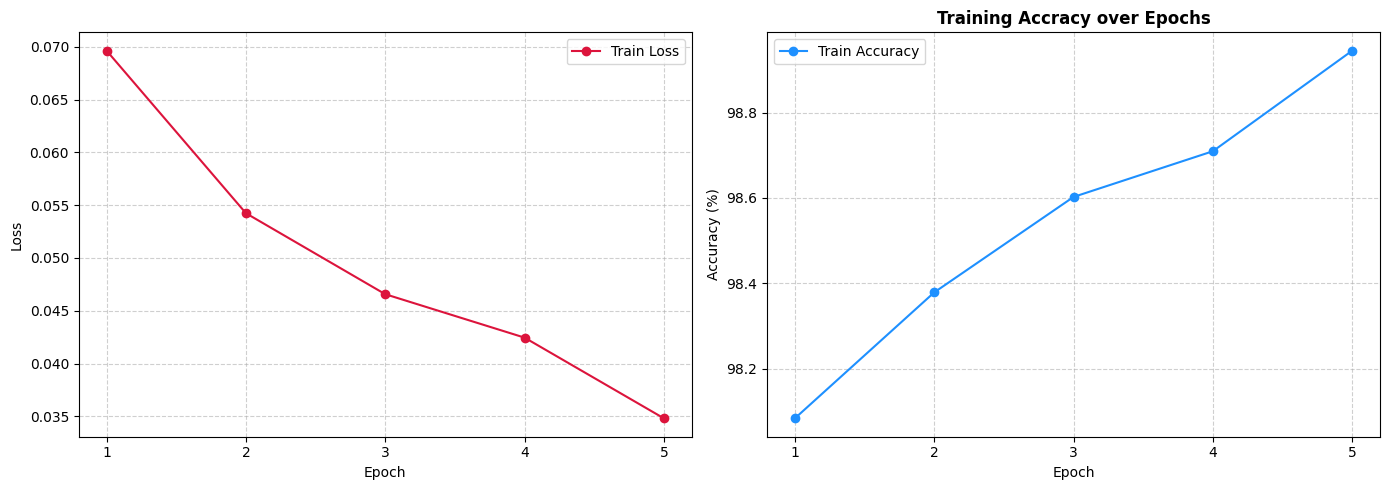

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, len(history_loss) + 1), history_loss, marker='o', color='crimson', label='Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_xticks(range(1, len(history_loss) + 1))
ax1.legend()

ax2.plot(range(1, len(history_acc) + 1), history_acc, marker='o', color='dodgerblue', label='Train Accuracy')
ax2.set_title('Training Accracy over Epochs', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_xticks(range(1, len(history_acc) + 1))
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
test_df = pd.read_csv('/root/.cache/kagglehub/competitions/digit-recognizer/test.csv')
test_images = test_df.values

X_test_tensor = torch.FloatTensor(test_images).view(-1, 1, 28, 28)

# 모델을 '평가 모드'로 변경 (Dropout 등을 끄고 시험 모드로 전환합니다.)
model.eval()

predictions = []

# 기울기 계산을 끄고(메모리 절약) 초고속 예측 시작
with torch.no_grad():
    X_test_tensor = X_test_tensor.to(device)

    outputs = model(X_test_tensor)

    # 가장 점수가 높은 숫자(0~9) 골라내기
    _, predicted = outputs.max(1)

    # 결과를 CPU로 다시 가져와서 리스트에 저장
    predictions = predicted.cpu().numpy()

submission = pd.DataFrame({
    'ImageId': range(1, len(predictions) + 1),
    'Label': predictions
})

submission.to_csv('submission.csv', index=False)
